# 07 — GFF3 Annotations

**Purpose:** Retrieve and analyze phage gene annotations stored in GFF3 format.

| | |
|---|---|
| **Expected inputs** | GFF3 files at `/data/processed/gff3/` and index at `gff3_index.json` |
| **Companion notebooks** | `01` database QC · `02` sequence retrieval |

---
## Setup

In [1]:
import os
from pathlib import Path

import pandas as pd
from pbi import GFF3Retriever

---
## 1. Initialize GFF3Retriever

The `GFF3Retriever` uses a pre-built JSON index for O(1) lookup of phage annotations.
The index maps each `phage_id` to its byte location in the per-database GFF3 files.

In [2]:
GFF3_DIR = Path(os.getenv('DATA_PATH', 'data/processed')) / 'gff3'
GFF3_INDEX = GFF3_DIR / 'gff3_index.json'

if not GFF3_INDEX.exists():
    raise FileNotFoundError(
        f'GFF3 index not found: {GFF3_INDEX}\n'
        'Run: docker compose run --rm pipeline snakemake --cores 4 download_all_gff3 build_gff3_index'
    )

gff3 = GFF3Retriever(str(GFF3_DIR), str(GFF3_INDEX))
stats = gff3.stats()

print(f'GFF3 index: {stats["total_phages"]:,} phages across {len(stats["sources"])} databases')
print(f'Path: {GFF3_INDEX}')

# Verify files are accessible (not broken symlinks)
sample_phages = gff3.list_phages(source_db=list(stats['sources'].keys())[0])[:1]
if sample_phages:
    test_content = gff3.get_gff3(sample_phages[0])
    if not test_content:
        print(f'\nWARNING: GFF3 files are broken symlinks. Mount the cache volume:')
        print(f'  In docker-compose.yml analysis service: pbi-cache:/cache:ro')
    else:
        print(f'File accessibility: OK ({len(test_content):,} bytes from {sample_phages[0]})')

GFF3 index: 1,320,747 phages across 22 databases
Path: /data/processed/gff3/gff3_index.json
File accessibility: OK (72,699 bytes from Mycobacterium_phage_NuevoMundo)


---
## 2. Index Overview

View the total phage count and breakdown by source database.

In [3]:
print(f'Total phages with GFF3 annotations: {stats["total_phages"]:,}')
print(f'\nSources ({len(stats["sources"])} databases):')
for source, count in sorted(stats['sources'].items(), key=lambda x: -x[1]):
    print(f'  {source:15s} {count:>8,}')

Total phages with GFF3 annotations: 1,320,747

Sources (22 databases):
  MetaVR           225,269
  GOV2             195,699
  MGV              189,680
  IMGVR            154,641
  GPD              142,809
  TemPhD            66,823
  ELGV              56,716
  CHVD              44,935
  URPC              44,633
  TYMEFLIES         44,192
  OVD               37,184
  GVD               31,402
  UHGV              21,176
  BAPS              18,590
  OPD               14,649
  IGVD              10,021
  GSV                4,518
  STV                4,065
  HPGC               3,872
  PhagesDB           3,754
  VMGC               3,485
  SVD                2,634


---
## 3. List Phages by Source

List all source databases or filter phages by a specific source.

In [4]:
source_databases = sorted(stats['sources'].keys())
print('Available source databases:')
for db in source_databases:
    print(f'  - {db}')

Available source databases:
  - BAPS
  - CHVD
  - ELGV
  - GOV2
  - GPD
  - GSV
  - GVD
  - HPGC
  - IGVD
  - IMGVR
  - MGV
  - MetaVR
  - OPD
  - OVD
  - PhagesDB
  - STV
  - SVD
  - TYMEFLIES
  - TemPhD
  - UHGV
  - URPC
  - VMGC


In [5]:
# List phages from a specific source
source_to_list = 'PhagesDB'  # Change this to explore other sources
phages_in_source = gff3.list_phages(source_db=source_to_list)

print(f'Phages in {source_to_list}: {len(phages_in_source):,}')
print(f'\nFirst 10 phages:')
for pid in sorted(phages_in_source)[:10]:
    print(f'  {pid}')

Phages in PhagesDB: 3,754

First 10 phages:
  Actinoplanes_phage_phiAsp2
  Arthrobacter_Hestia_complete
  Arthrobacter_phage_Abba
  Arthrobacter_phage_Abidatro
  Arthrobacter_phage_Adaia
  Arthrobacter_phage_Adat
  Arthrobacter_phage_Adolin
  Arthrobacter_phage_Adumb2043
  Arthrobacter_phage_Aledel
  Arthrobacter_phage_Amelia


---
## 4. Retrieve GFF3 for a Single Phage

The `get_gff3()` method returns the raw GFF3 content as a string.

In [6]:
# Pick a phage from the list above
sample_phage = sorted(phages_in_source)[0] if phages_in_source else None

if sample_phage:
    print(f'Retrieving GFF3 for: {sample_phage}')
    print(f'Source database: {gff3.get_source_db(sample_phage)}')
    
    content = gff3.get_gff3(sample_phage)
    if content:
        print(f'\nGFF3 content ({len(content):,} bytes):')
        print('-' * 60)
        for line in content.split('\n')[:30]:
            print(line)
        total_lines = len(content.split('\n'))
        if total_lines > 30:
            print(f'... ({total_lines} total lines)')
    else:
        print(f'No GFF3 content found (file may be empty or broken symlink)')

Retrieving GFF3 for: Actinoplanes_phage_phiAsp2
Source database: PhagesDB

GFF3 content (23,666 bytes):
------------------------------------------------------------
# Sequence Data: seqnum=2149;seqlen=58638;seqhdr="Actinoplanes_phage_phiAsp2"
# Model Data: version=Prodigal.v2.6.3;run_type=Single;model="Ab initio";gc_cont=63.21;transl_table=11;uses_sd=1
Actinoplanes_phage_phiAsp2	Prodigal_v2.6.3	CDS	1	357	40.4	+	0	ID=2149_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.686;conf=99.99;score=40.41;cscore=37.19;sscore=3.22;rscore=0.00;uscore=0.00;tscore=3.22;product=unknown;protein_id=Actinoplanes_phage_phiAsp2_1
Actinoplanes_phage_phiAsp2	Prodigal_v2.6.3	CDS	350	640	40.9	+	0	ID=2149_2;partial=00;start_type=GTG;rbs_motif=AGxAGG/AGGxGG;rbs_spacer=5-10bp;gc_cont=0.722;conf=99.99;score=40.87;cscore=36.72;sscore=4.16;rscore=7.32;uscore=-1.07;tscore=-3.34;product=unknown;protein_id=Actinoplanes_phage_phiAsp2_2
Actinoplanes_phage_phiAsp2	Prodigal_v2.6.3	CDS	693	1013	37.9	+	

---
## 5. Memory-Efficient Line Iterator

For large files, use `get_gff3_lines()` to iterate line by line without loading everything into memory.

In [7]:
if sample_phage:
    print(f'Iterating GFF3 lines for: {sample_phage}\n')
    
    line_count = 0
    cds_count = 0
    for line in gff3.get_gff3_lines(sample_phage):
        line_count += 1
        if line.startswith('#'):
            continue
        fields = line.strip().split('\t')
        if len(fields) >= 9 and fields[2] == 'CDS':
            cds_count += 1
            if cds_count <= 5:
                print(f'CDS: {fields[0]}:{fields[3]}-{fields[4]} ({fields[6]})')
    
    print(f'\nTotal lines: {line_count}')
    print(f'CDS features: {cds_count}')

Iterating GFF3 lines for: Actinoplanes_phage_phiAsp2

CDS: Actinoplanes_phage_phiAsp2:1-357 (+)
CDS: Actinoplanes_phage_phiAsp2:350-640 (+)
CDS: Actinoplanes_phage_phiAsp2:693-1013 (+)
CDS: Actinoplanes_phage_phiAsp2:1019-2959 (+)
CDS: Actinoplanes_phage_phiAsp2:3039-3863 (+)

Total lines: 79
CDS features: 77


---
## 6. Parse GFF3 into a DataFrame

Parse GFF3 lines into a structured pandas DataFrame for analysis.

In [8]:
GFF3_COLUMNS = ['seqid', 'source', 'type', 'start', 'end',
                'score', 'strand', 'phase', 'attributes',
                'ID', 'product', 'protein_id']


def parse_gff3_attributes(attr_string):
    """Parse GFF3 attributes column into a dictionary."""
    attrs = {}
    if not attr_string or attr_string == '.':
        return attrs
    for pair in attr_string.split(';'):
        if '=' in pair:
            key, value = pair.split('=', 1)
            attrs[key.strip()] = value.strip()
    return attrs


def gff3_to_dataframe(gff3_content):
    """Parse GFF3 content into a DataFrame."""
    rows = []
    for line in gff3_content.split('\n'):
        if line.startswith('#') or not line.strip():
            continue
        fields = line.strip().split('\t')
        if len(fields) >= 9:
            attrs = parse_gff3_attributes(fields[8])
            rows.append({
                'seqid': fields[0], 'source': fields[1], 'type': fields[2],
                'start': int(fields[3]), 'end': int(fields[4]),
                'score': fields[5], 'strand': fields[6], 'phase': fields[7],
                'attributes': fields[8],
                'ID': attrs.get('ID', ''), 'product': attrs.get('product', ''),
                'protein_id': attrs.get('protein_id', ''),
            })
    if not rows:
        return pd.DataFrame(columns=GFF3_COLUMNS)
    return pd.DataFrame(rows)


if sample_phage:
    content = gff3.get_gff3(sample_phage)
    df = gff3_to_dataframe(content)
    print(f'Parsed GFF3 for: {sample_phage}')
    print(f'Total features: {len(df)}')
    if df.empty:
        print('No features found in GFF3 content for this phage')
    else:
        print(f'\nFeature types:')
        print(df['type'].value_counts().to_string())
        print(f'\nCDS features (first 10):')
        df_cds = df[df['type'] == 'CDS'].head(10)
        display(df_cds[['seqid', 'start', 'end', 'strand', 'ID', 'product']])

Parsed GFF3 for: Actinoplanes_phage_phiAsp2
Total features: 77

Feature types:
type
CDS    77

CDS features (first 10):


,seqid,start,end,strand,ID,product
0,Actinoplanes_phage_phiAsp2,1,357,+,2149_1,unknown
1,Actinoplanes_phage_phiAsp2,350,640,+,2149_2,unknown
2,Actinoplanes_phage_phiAsp2,693,1013,+,2149_3,Protein of unknown function (DUF1360)
3,Actinoplanes_phage_phiAsp2,1019,2959,+,2149_4,hypothetical protein
4,Actinoplanes_phage_phiAsp2,3039,3863,+,2149_5,Phage Mu protein F like protein
5,Actinoplanes_phage_phiAsp2,3884,5326,+,2149_6,hypothetical protein
6,Actinoplanes_phage_phiAsp2,5330,5476,+,2149_7,unknown
7,Actinoplanes_phage_phiAsp2,5567,5776,-,2149_8,unknown
8,Actinoplanes_phage_phiAsp2,5804,6028,-,2149_9,unknown
9,Actinoplanes_phage_phiAsp2,6087,6341,-,2149_10,unknown


---
## 7. Gene Length Distribution

Analyze the distribution of gene lengths from GFF3 annotations.

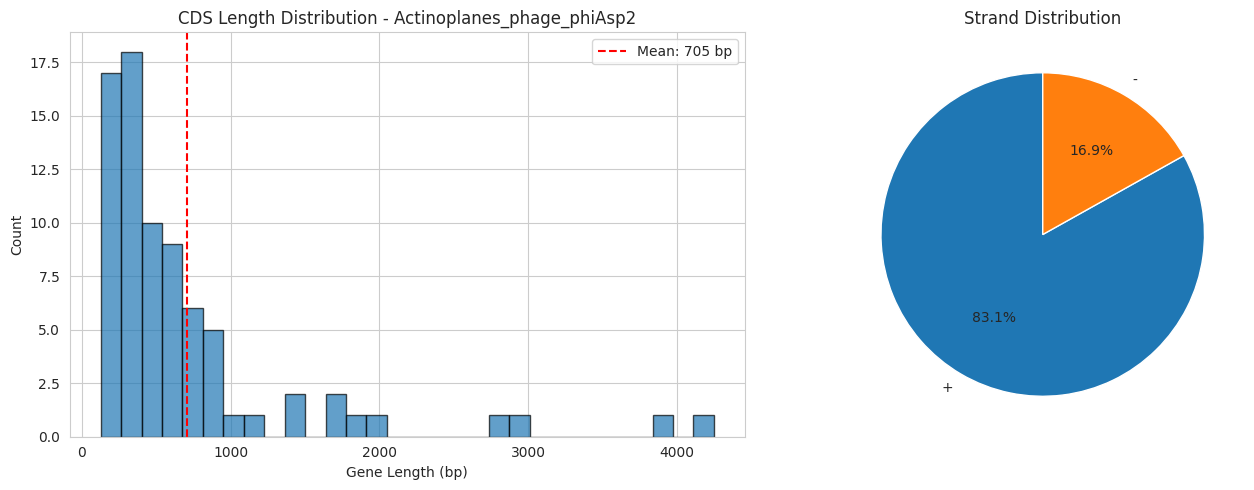

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

if sample_phage and not df.empty:
    df['length'] = df['end'] - df['start'] + 1
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cds_lengths = df[df['type'] == 'CDS']['length']
    if len(cds_lengths) > 0:
        axes[0].hist(cds_lengths, bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Gene Length (bp)')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'CDS Length Distribution - {sample_phage}')
        axes[0].axvline(cds_lengths.mean(), color='red', linestyle='--', 
                       label=f'Mean: {cds_lengths.mean():.0f} bp')
        axes[0].legend()
    
    strand_counts = df[df['type'] == 'CDS']['strand'].value_counts()
    if len(strand_counts) > 0:
        axes[1].pie(strand_counts.values, labels=strand_counts.index, 
                   autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Strand Distribution')
    
    plt.tight_layout()
    plt.show()

---
## 8. Check if a Phage Exists

Use `has_phage()` to quickly check if a phage has GFF3 annotations.

In [10]:
test_phages = [
    'Mycobacterium_phage_NuevoMundo',
    'Escherichia_phage_T4',
    'Nonexistent_phage_test',
]

for phage_id in test_phages:
    exists = gff3.has_phage(phage_id)
    status = 'FOUND' if exists else 'NOT FOUND'
    print(f'{phage_id}: {status}')

Mycobacterium_phage_NuevoMundo: FOUND
Escherichia_phage_T4: NOT FOUND
Nonexistent_phage_test: NOT FOUND


---
## 9. Integration with Phage Metadata

Combine GFF3 annotations with phage metadata from the DuckDB database. Note all phages have a GFF3 record associated.

In [17]:
import pbi

try:
    retriever = pbi.quick_connect()
    print('Connected to database')
    
    phage_metadata = retriever.get_phage_metadata(limit=10000)
    print(f'Retrieved metadata for {len(phage_metadata)} phages')
    
    phage_ids = phage_metadata['Phage_ID'].tolist()
    has_gff3 = [gff3.has_phage(pid) for pid in phage_ids]
    phage_metadata['has_gff3'] = has_gff3
    
    print(f'\nPhages with GFF3: {sum(has_gff3)} / {len(has_gff3)}')
    display(phage_metadata[['Phage_ID', 'Source_DB', 'Length', 'has_gff3']].head(10))
    
    retriever.close()
except Exception as e:
    print(f'Database connection failed: {e}')

2026-09-10 04:55:43,449 - INFO - 📂 Checking FASTA index files:
2026-09-10 04:55:43,465 - INFO -    Phage index: True (82826.5 KB)
2026-09-10 04:55:43,477 - INFO -    Protein index: True (4376442.2 KB)
2026-09-10 04:55:43,489 - INFO - 📂 Loaded private phage mapping for 1 sources: ['test_private']
2026-09-10 04:55:43,666 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-09-10 04:55:43,688 - INFO -    Loaded mapping for 5363 hosts
2026-09-10 04:55:43,691 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-09-10 04:55:43,772 - INFO - 🔄 Starting background FASTA loading...
2026-09-10 04:55:43,776 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-09-10 04:55:43,776 - INFO - ✅ Initialization complete (FASTA loading in background)
2026-09-10 04:55:43,795 - INFO - 🔍 Querying phage metadata...


Connected to database


2026-09-10 04:55:44,016 - INFO - ✅ Retrieved metadata for 10,000 phages


Retrieved metadata for 10000 phages

Phages with GFF3: 2831 / 10000


,Phage_ID,Source_DB,Length,has_gff3
0,NC_001330.1,RefSeq,6087,False
1,NC_001331.1,RefSeq,7349,False
2,NC_001332.1,RefSeq,6744,False
3,NC_001335.1,RefSeq,52297,False
4,NC_001341.1,RefSeq,4491,False
5,NC_001365.1,RefSeq,8273,False
6,NC_001396.1,RefSeq,7308,False
7,NC_002014.1,RefSeq,6883,False
8,NC_001416.1,RefSeq,48502,False
9,NC_001418.1,RefSeq,5833,False


2026-09-10 04:55:44,189 - INFO - 🔒 Database connection closed
2026-09-10 04:55:53,135 - INFO -    ✅ Phage FASTA loaded in 9.36s (1,327,915 sequences)
2026-09-10 04:55:53,139 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta


---
## 10. Batch Retrieval

Retrieve GFF3 annotations for multiple phages and combine them.

In [12]:
source_for_batch = 'PhagesDB'
phages_for_batch = gff3.list_phages(source_db=source_for_batch)[:5]

print(f'Batch retrieving GFF3 for {len(phages_for_batch)} phages from {source_for_batch}:\n')

all_cds = []
for phage_id in phages_for_batch:
    content = gff3.get_gff3(phage_id)
    if content:
        df_phage = gff3_to_dataframe(content)
        df_cds = df_phage[df_phage['type'] == 'CDS'].copy()
        df_cds['phage_id'] = phage_id
        all_cds.append(df_cds)
        print(f'  {phage_id}: {len(df_cds)} CDS features')

if all_cds:
    combined_df = pd.concat(all_cds, ignore_index=True)
    print(f'\nTotal CDS across all phages: {len(combined_df)}')
    products = combined_df[combined_df['product'] != '']['product'].head(10)
    if not products.empty:
        print(f'\nSample products:')
        for prod in products:
            print(f'  - {prod}')

Batch retrieving GFF3 for 5 phages from PhagesDB:

  Mycobacterium_phage_NuevoMundo: 232 CDS features
  Mycobacterium_phage_Phusco: 226 CDS features
  Mycobacterium_phage_Goose: 78 CDS features
  Mycobacterium_phage_Kloppinator: 99 CDS features
  Mycobacterium_phage_Yoshi: 106 CDS features

Total CDS across all phages: 741

Sample products:
  - unknown
  - unknown
  - Predicted nucleotidyltransferase
  - unknown
  - unknown
  - hypothetical protein
  - hypothetical protein
  - unknown
  - unknown
  - hypothetical protein


---
## 11. Coverage Analysis

Cross-reference phages in DuckDB with the GFF3 index to determine annotation coverage.

In [13]:
import pbi

try:
    seq_retriever = pbi.quick_connect()
    print('Connected to database')
    
    all_phages_df = seq_retriever.get_phage_metadata(limit=100000)
    print(f'Total phages in DuckDB: {len(all_phages_df):,}')
    
    gff3_stats = gff3.stats()
    print(f'Total phages in GFF3 index: {gff3_stats["total_phages"]:,}')
    
    print(f'\nCoverage by source database:')
    print(f'{"Source":<15} {"DuckDB":>10} {"GFF3":>10} {"Coverage":>10}')
    print('-' * 50)
    
    for source in sorted(all_phages_df['Source_DB'].unique()):
        db_count = len(all_phages_df[all_phages_df['Source_DB'] == source])
        gff3_count = gff3_stats['sources'].get(source, 0)
        coverage = (gff3_count / db_count * 100) if db_count > 0 else 0
        print(f'{source:<15} {db_count:>10,} {gff3_count:>10,} {coverage:>9.1f}%')
    
    seq_retriever.close()
except Exception as e:
    print(f'Database connection failed: {e}')

2026-09-10 04:55:05,316 - INFO - 📂 Checking FASTA index files:
2026-09-10 04:55:05,343 - INFO -    Phage index: True (82826.5 KB)
2026-09-10 04:55:05,391 - INFO -    Protein index: True (4376442.2 KB)
2026-09-10 04:55:05,990 - INFO -    ✅ Phage FASTA loaded in 11.25s (1,327,915 sequences)
2026-09-10 04:55:05,990 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta
2026-09-10 04:55:05,992 - INFO - 📂 Loaded private phage mapping for 1 sources: ['test_private']
2026-09-10 04:55:05,994 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-09-10 04:55:06,001 - INFO -    Loaded mapping for 5363 hosts
2026-09-10 04:55:06,001 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-09-10 04:55:06,116 - INFO - 🔄 Starting background FASTA loading...
2026-09-10 04:55:06,119 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-09-10 04:55:06,1

Connected to database


2026-09-10 04:55:12,982 - INFO - ✅ Retrieved metadata for 100,000 phages


Total phages in DuckDB: 100,000
Total phages in GFF3 index: 1,320,747

Coverage by source database:
Source              DuckDB       GFF3   Coverage
--------------------------------------------------
DDBJ                   290          0       0.0%
EMBL                   156          0       0.0%
GPD                 57,675    142,809     247.6%


2026-09-10 04:55:17,564 - INFO -    ✅ Phage FASTA loaded in 11.44s (1,327,915 sequences)
2026-09-10 04:55:17,566 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta


GVD                 31,402     31,402     100.0%
Genbank              2,086          0       0.0%
PhagesDB             3,754      3,754     100.0%


2026-09-10 04:55:17,836 - INFO - 🔒 Database connection closed


RefSeq               4,637          0       0.0%


---
## 12. Annotation Quality

Analyze the quality of GFF3 annotations by checking how many
CDS features have meaningful product annotations vs hypothetical/unknown.

In [14]:
sources_to_sample = ['RefSeq', 'PhagesDB', 'Genbank']
sample_size = 10

print(f'Annotation quality analysis (sampling {sample_size} phages per source)\n')

for source in sources_to_sample:
    phages = gff3.list_phages(source_db=source)
    if not phages:
        print(f'{source}: No phages in GFF3 index')
        continue
    
    sampled = sorted(phages)[:sample_size]
    total_cds = with_product = hypothetical = unknown = 0
    
    for phage_id in sampled:
        content = gff3.get_gff3(phage_id)
        df = gff3_to_dataframe(content)
        cds_df = df[df['type'] == 'CDS']
        
        total_cds += len(cds_df)
        with_product += len(cds_df[cds_df['product'] != ''])
        hypothetical += len(cds_df[cds_df['product'].str.contains('hypothetical', case=False, na=False)])
        unknown += len(cds_df[cds_df['product'].str.contains('unknown', case=False, na=False)])
    
    annotated = with_product - hypothetical - unknown
    print(f'{source}:')
    print(f'  Total CDS: {total_cds}')
    print(f'  With product: {with_product} ({with_product/total_cds*100:.1f}%)')
    print(f'  Annotated: {annotated} ({annotated/total_cds*100:.1f}%)')
    print(f'  Hypothetical: {hypothetical} ({hypothetical/total_cds*100:.1f}%)')
    print(f'  Unknown: {unknown} ({unknown/total_cds*100:.1f}%)\n')

Annotation quality analysis (sampling 10 phages per source)

RefSeq: No phages in GFF3 index
PhagesDB:
  Total CDS: 630
  With product: 630 (100.0%)
  Annotated: 160 (25.4%)
  Hypothetical: 120 (19.0%)
  Unknown: 350 (55.6%)

Genbank: No phages in GFF3 index


---
## 13. Feature Type Breakdown

Analyze the distribution of feature types (gene, CDS, etc.) across source databases.

In [15]:
sources_to_analyze = list(gff3.stats()['sources'].keys())[:5]
sample_size = 5

print(f'Feature type analysis by source database (sampling {sample_size} phages each)\n')

feature_data = []

for source in sources_to_analyze:
    phages = gff3.list_phages(source_db=source)
    if not phages:
        continue
    
    sampled = sorted(phages)[:sample_size]
    feature_counts = {}
    
    for phage_id in sampled:
        content = gff3.get_gff3(phage_id)
        df = gff3_to_dataframe(content)
        for feat_type in df['type'].unique():
            feature_counts[feat_type] = feature_counts.get(feat_type, 0) + len(df[df['type'] == feat_type])
    
    for feat_type, count in sorted(feature_counts.items(), key=lambda x: -x[1]):
        feature_data.append({'source': source, 'feature_type': feat_type, 'count': count})
    
    print(f'{source}:')
    for feat_type, count in sorted(feature_counts.items(), key=lambda x: -x[1]):
        print(f'  {feat_type}: {count}')
    print()

if feature_data:
    feature_df = pd.DataFrame(feature_data)
    print('Summary across all sampled sources:')
    summary = feature_df.groupby('feature_type')['count'].sum().sort_values(ascending=False)
    for feat_type, total in summary.items():
        print(f'  {feat_type}: {total:,}')

Feature type analysis by source database (sampling 5 phages each)

PhagesDB:
  CDS: 322

GPD:
  CDS: 267

GVD:
  CDS: 51

SVD:
  CDS: 120

MGV:
  CDS: 19

Summary across all sampled sources:
  CDS: 779


---
## Summary

### Key Takeaways

1. **`GFF3Retriever`** provides O(1) access to phage gene annotations
2. **Raw GFF3** is preserved for full fidelity; parse as needed
3. **Coverage analysis** reveals annotation completeness per source
4. **Annotation quality** shows meaningful vs hypothetical/unknown products

### API Reference

| Method | Description |
|--------|-------------|
| `get_gff3(phage_id)` | Return full GFF3 content as string |
| `get_gff3_lines(phage_id)` | Yield GFF3 lines (memory-efficient) |
| `list_phages(source_db=)` | List all phage IDs, optionally filtered |
| `has_phage(phage_id)` | Check if phage exists in index |
| `get_source_db(phage_id)` | Get source database for a phage |
| `stats()` | Get index statistics |